In [ ]:
# Importe Librerias
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, date_format, last_day
from IPython.display import display
from PIL import Image
import calendar
import sys
import os


In [ ]:
# Conexión a bd
sys.path.append(os.path.abspath(os.path.dirname(__file__) + "/.."))

from db_conexion import get_spark_session, load_table, write_table

spark = get_spark_session()

In [21]:
# Generar diccionarios de datos para tablas

clientes_df = spark.read.csv("../csv/clientes.csv", header=True, inferSchema=True)
productos_df = spark.read.csv("../csv/productos.csv", header=True, inferSchema=True)
corresponsal_df = spark.read.csv("../csv/corresponsales.csv", header=True, inferSchema=True)
ordenes_df = spark.read.csv("../csv/ordenes.csv", header=True, inferSchema=True)
detalles_ordenes_df = spark.read.csv("../csv/detalle_orden.csv", header=True, inferSchema=True)

# Convertir fechas a formato adecuado
ordenes_df = ordenes_df.withColumn("fecha", date_format(col("fecha"), "yyyy-MM-dd"))

# Obtener fechas únicas
fechas_unicas = ordenes_df.select("fecha").distinct().collect()

for row in fechas_unicas:
    fecha = row["fecha"]
    año, mes = fecha[:7].split("-")

    ultimo_dia_mes_actual = f"{año}-{mes}-{calendar.monthrange(int(año), int(mes))[1]}"
    mes_inicio = f"{año}-{mes}-01"

    spark.sql(f"""
        CREATE TABLE IF NOT EXISTS ordenes_{fecha[:7].replace('-', '_')} PARTITION OF ordenes
        FOR VALUES FROM ('{mes_inicio}') TO ('{ultimo_dia_mes_actual}'::DATE + INTERVAL '1 day');
    """)

print("Tablas creadas dinámicamente según fechas únicas")




Datos insertados correctamente.


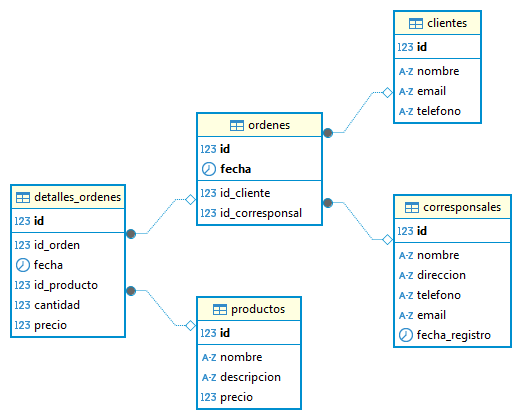

In [22]:
# Insertar datos en base de datos
write_table(clientes_df, "clientes")
write_table(productos_df, "productos")
write_table(corresponsal_df, "corresponsales")
write_table(ordenes_df, "ordenes")


# validar que las fechas existan

ordenes_validas = set(ordenes_df.select("id", "fecha").collect())

detalles_ordenes_df = detalles_ordenes_df.filter(
    col("id_orden"), col("fecha")).isin(ordenes_validas)
# end validacion

write_table(detalles_ordenes_df, "detalles_ordenes")


print("Datos insertados correctamente.")



imagen = Image.open("Entidad-Relacion.png")
display(imagen)



# Cerrar conexión
cur.close()
conn.close()